# MedScan Diagnostics — Blood Cell Detection with YOLO
**Dataset:** BCCD (Blood Cell Count and Detection)  
**Model:** YOLOv26 (Ultralytics) 
**Classes:** RBC (Red Blood Cell), WBC (White Blood Cell), Platelet  
**Objective:** Train an object detection model, evaluate performance, and assess clinical deployment viability.

## 1. Install Dependencies

In [1]:
# Install required packages
%pip install -r ../requirements.txt --quiet

import ultralytics
ultralytics.checks()


Ultralytics 8.4.19  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
Setup complete  (12 CPUs, 15.9 GB RAM, 348.5/464.9 GB disk)


## 2. Import Libraries

In [2]:
import os
import yaml
import random
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import display, Image
from collections import Counter
from pathlib import Path
from PIL import Image as PILImage
import cv2
import matplotlib.patches as patches

from ultralytics import YOLO
from roboflow import Roboflow

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)

# ── Project folder structure ──────────────────────────────────────────
# data/raw/        — downloaded BCCD-3 dataset (images + labels)
# data/processed/  — reserved for any preprocessing outputs
# models/          — best .pt weights saved here after each experiment
# results/figures/ — all PNG charts / confusion matrices
# results/metrics/ — CSV files with per-run metrics
# notebooks/       — this notebook lives here
# notebooks/runs/  — Ultralytics training artefacts (auto-generated)

DIRS = [
    Path("../data/raw"),
    Path("../data/processed"),
    Path("../models"),
    Path("../results/figures"),
    Path("../results/metrics"),
]
for d in DIRS:
    d.mkdir(parents=True, exist_ok=True)

print("All libraries imported successfully.")
print("Project directory structure:")
for d in DIRS:
    print(f"  {d}")


All libraries imported successfully.
Project directory structure:
  ..\data\raw
  ..\data\processed
  ..\models
  ..\results\figures
  ..\results\metrics


## 3. Load the BCCD Dataset from Roboflow

> **Instructions:**  
> 1. Create a free account at [roboflow.com](https://roboflow.com)  
> 2. Go to [Roboflow Universe — BCCD Dataset](https://universe.roboflow.com/roboflow-100/bccd-ue3dp)  
> 3. Click **Download** → choose **YOLOv26** format for → select **Show Download Code**  
> 4. Copy your API key and paste it below

In [23]:
# ── Replace with your own Roboflow API key ────────────────────────────
ROBOFLOW_API_KEY = "3gbxQ0DCCQhhl4BVojvG"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("joseph-nelson").project("bccd")
version  = project.version(3)

# Download into data/raw/ so it lives in the right place
dataset = version.download("yolo26", location="../data/raw/BCCD-3")
print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: c:\Users\jchen\MiniProject7-BloodCellDetection\data\raw\BCCD-3


## 4. Verify Dataset Structure

In [4]:
dataset_path = Path(dataset.location)
for split in ["train", "valid", "test"]:
    images = list((dataset_path / split / "images").glob("*")) if (dataset_path / split / "images").exists() else []
    labels = list((dataset_path / split / "labels").glob("*")) if (dataset_path / split / "labels").exists() else []
    print(f"{split:>6}: {len(images):>4} images | {len(labels):>4} labels")

yaml_path = dataset_path / "data.yaml"
with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print("\n--- data.yaml ---")
print(yaml.dump(data_config, default_flow_style=False))
class_names = data_config["names"]

 train:  255 images |  255 labels
 valid:   73 images |   73 labels
  test:   36 images |   36 labels

--- data.yaml ---
names:
- Platelets
- RBC
- WBC
nc: 3
roboflow:
  license: MIT
  project: bccd
  url: https://universe.roboflow.com/joseph-nelson/bccd/dataset/3
  version: 3
  workspace: joseph-nelson
test: ../test/images
train: ../train/images
val: ../valid/images



## 5. Class Distribution

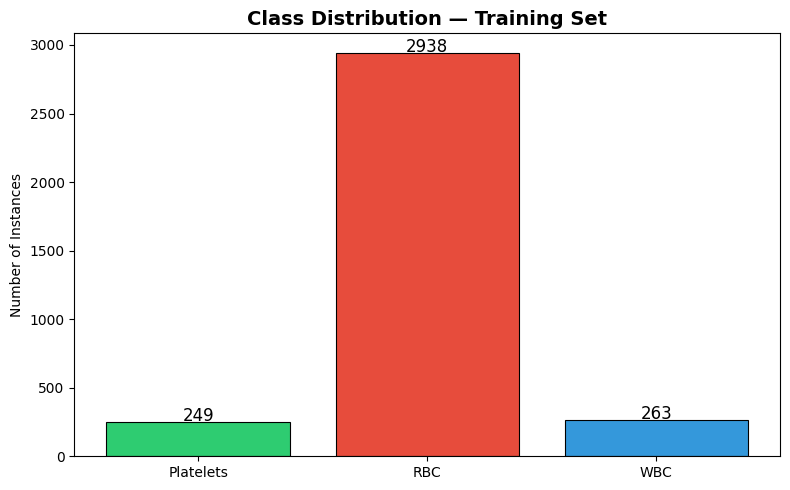


Class Distribution:
  Platelets :   249 instances
  RBC       :  2938 instances
  WBC       :   263 instances

Note: RBC dominates (~85% of instances), creating class imbalance.


In [6]:
labels_dir = dataset_path / "train" / "labels"
class_counts = Counter()
for label_file in labels_dir.glob("*.txt"):
    with open(label_file) as f:
        for line in f:
            class_counts[int(line.strip().split()[0])] += 1

labels = [class_names[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts, color=["#2ecc71", "#e74c3c", "#3498db"], edgecolor="black", linewidth=0.8)
ax.set_title("Class Distribution — Training Set", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Instances")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(count), ha="center", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClass Distribution:")
for name, count in zip(labels, counts):
    print(f"  {name:<10}: {count:>5} instances")
print(f"\nNote: RBC dominates (~{counts[1]/(sum(counts))*100:.0f}% of instances), creating class imbalance.")

## 6. Visualize Sample Training Images

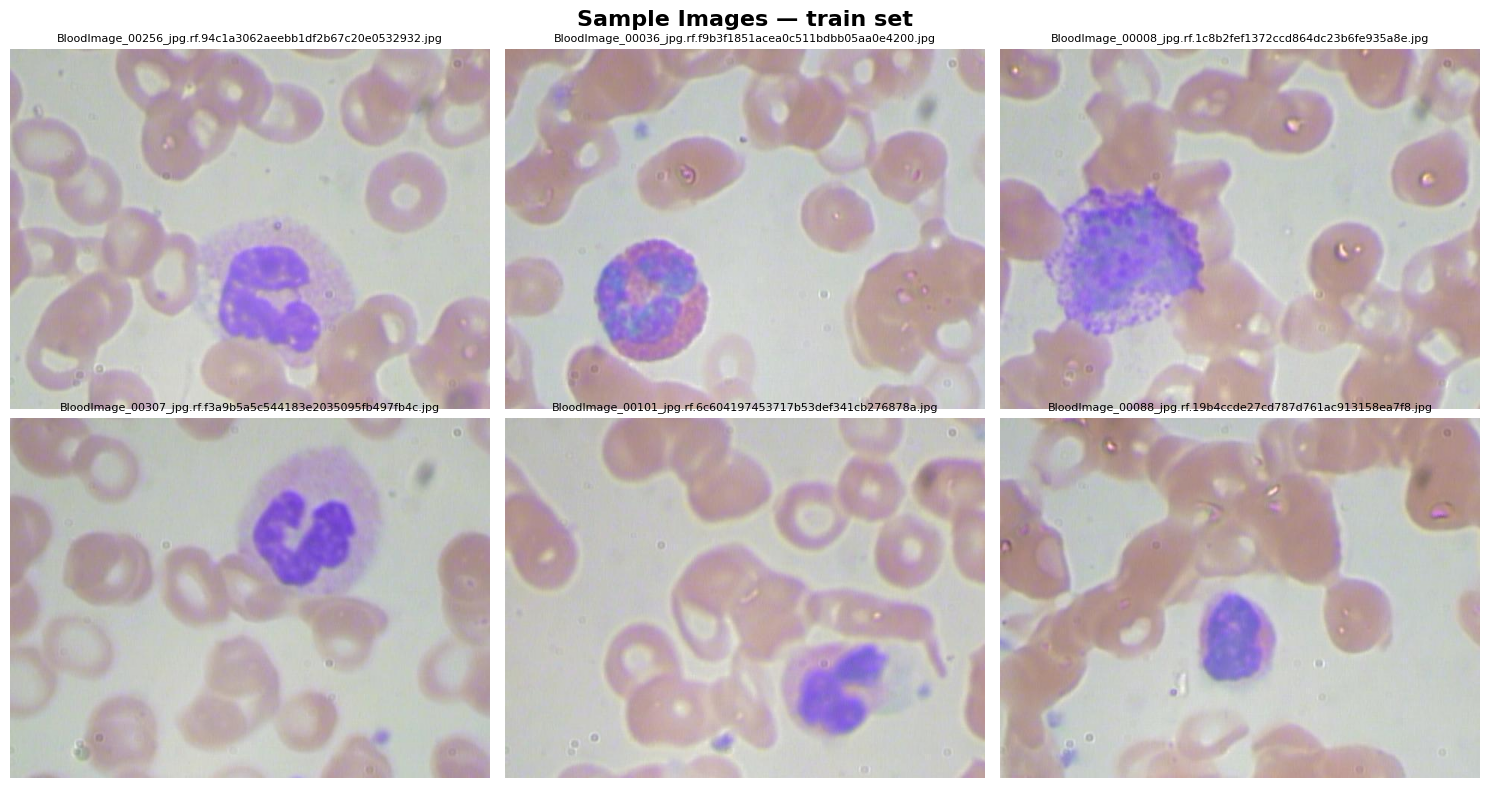

Saved: ../results/figures/sample_images.png


In [7]:
def plot_sample_images(dataset_path, split="train", n=6, save_path=None):
    images_dir = Path(dataset_path) / split / "images"
    image_files = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))
    sample = random.sample(image_files, min(n, len(image_files)))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Sample Images — {split} set", fontsize=16, fontweight="bold")
    for ax, img_path in zip(axes.flatten(), sample):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    out = save_path or "../results/figures/sample_images.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

plot_sample_images(dataset.location, split="train")

## 6. Load Pre-trained YOLO Model (COCO Weights)

In [ ]:
# Load YOLOv26 nano model pre-trained on COCO
model = YOLO("yolo26n.pt")

print("Model loaded successfully.")
print(f"Model type: {type(model)}")
model.info()

Model loaded successfully.
Model type: <class 'ultralytics.models.yolo.model.YOLO'>
YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs


(260, 2572280, 0, 6.1192448)

## 7. Hyperparameter Experiments

We test **four configurations** to find the best model:

| Run | Batch | Image Size | Notes |
|-----|-------|------------|-------|
| A   | 16    | 416        | Smaller input, faster training |
| B   | 16    | 640        | Default — our baseline |
| C   | 8     | 416        | Smaller batch, may generalize better |
| D   | 8     | 640        | Larger input + smaller batch |

All runs use **YOLO26n** pretrained on COCO, trained for **25 epochs**.

In [8]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Experiment grid ────────────────────────────────────────────────────
EXPERIMENTS = [
    {"name": "run_A_batch16_imgsz416", "batch": 16, "imgsz": 416},
    {"name": "run_B_batch16_imgsz640", "batch": 16, "imgsz": 640},
    {"name": "run_C_batch8_imgsz416",  "batch": 8,  "imgsz": 416},
    {"name": "run_D_batch8_imgsz640",  "batch": 8,  "imgsz": 640},
]

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"\nWill run {len(EXPERIMENTS)} experiments on device: {DEVICE}")

CUDA available: True
GPU: NVIDIA GeForce RTX 3060

Will run 4 experiments on device: 0


In [9]:
# ── Train all experiments ──────────────────────────────────────────────
# Each run saves its Ultralytics artefacts under notebooks/runs/detect/<name>
# After training we copy best.pt to models/<name>_best.pt

run_results = {}  # name -> metrics dict

for exp in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"  Starting: {exp['name']}  (batch={exp['batch']}, imgsz={exp['imgsz']})")
    print(f"{'='*60}")

    model = YOLO("yolo26n.pt")
    train_result = model.train(
        data=str(yaml_path),
        epochs=25,
        imgsz=exp["imgsz"],
        batch=exp["batch"],
        name=exp["name"],
        project="runs/detect",
        pretrained=True,
        patience=10,
        save=True,
        plots=True,
        device=DEVICE,
        verbose=False,
    )

    save_dir = Path(train_result.save_dir)
    best_pt  = save_dir / "weights" / "best.pt"

    # Copy best weights into models/
    import shutil
    dest = Path("../models") / f"{exp['name']}_best.pt"
    shutil.copy2(best_pt, dest)
    print(f"  Weights saved → {dest}")

    # Validate the best model and record metrics
    best_model = YOLO(str(best_pt))
    metrics = best_model.val(data=str(yaml_path), split="val", plots=False, verbose=False)

    run_results[exp["name"]] = {
        "batch":      exp["batch"],
        "imgsz":      exp["imgsz"],
        "mAP50":      round(metrics.box.map50, 4),
        "mAP50_95":   round(metrics.box.map,   4),
        "precision":  round(metrics.box.mp,    4),
        "recall":     round(metrics.box.mr,    4),
        "ap50_platelet": round(metrics.box.ap50[0], 4),
        "ap50_rbc":      round(metrics.box.ap50[1], 4),
        "ap50_wbc":      round(metrics.box.ap50[2], 4),
        "save_dir":   str(save_dir),
        "best_pt":    str(dest),
    }
    print(f"  mAP@50 = {run_results[exp['name']]['mAP50']}")

print("\n✅ All experiments complete.")


  Starting: run_A_batch16_imgsz416  (batch=16, imgsz=416)
Ultralytics 8.4.19  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\jchen\MiniProject7-BloodCellDetection\data\raw\BCCD-3\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run

## 8. Compare Results Across Runs

In [10]:
# ── Build comparison DataFrame ─────────────────────────────────────────
df_results = pd.DataFrame(run_results).T.reset_index()
df_results.rename(columns={"index": "run"}, inplace=True)

# Save to results/metrics/
metrics_csv = Path("../results/metrics/hyperparameter_comparison.csv")
df_results.drop(columns=["save_dir","best_pt"]).to_csv(metrics_csv, index=False)
print(f"Metrics saved → {metrics_csv}\n")

# Pretty-print table
cols = ["run","batch","imgsz","mAP50","mAP50_95","precision","recall",
        "ap50_platelet","ap50_rbc","ap50_wbc"]
print(df_results[cols].to_string(index=False))

Metrics saved → ..\results\metrics\hyperparameter_comparison.csv

                   run batch imgsz   mAP50 mAP50_95 precision  recall ap50_platelet ap50_rbc ap50_wbc
run_A_batch16_imgsz416    16   416  0.8622   0.6082    0.7779  0.8527        0.7881   0.8209   0.9776
run_B_batch16_imgsz640    16   640  0.8671    0.627    0.8195  0.8253        0.8168   0.8057   0.9787
 run_C_batch8_imgsz416     8   416  0.8542   0.6109     0.757  0.8289        0.7765   0.8194   0.9667
 run_D_batch8_imgsz640     8   640  0.8541   0.6092    0.7839  0.8153        0.7629   0.8222   0.9772


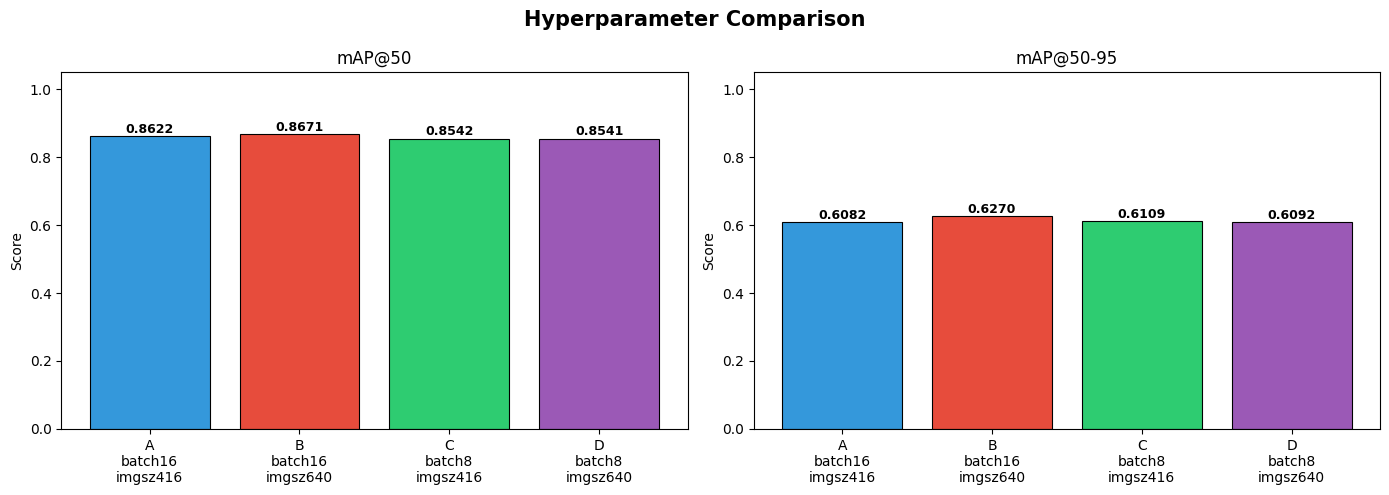

Saved: ../results/figures/hyperparameter_comparison_map.png


In [11]:
# ── Bar chart — mAP@50 per run ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hyperparameter Comparison", fontsize=15, fontweight="bold")

run_labels = df_results["run"].str.replace("run_", "").str.replace("_", "\n")
colors     = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]

# mAP@50
ax = axes[0]
bars = ax.bar(run_labels, df_results["mAP50"].astype(float), color=colors, edgecolor="black", linewidth=0.8)
ax.set_title("mAP@50")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, df_results["mAP50"].astype(float)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.4f}",
            ha="center", fontsize=9, fontweight="bold")

# mAP@50-95
ax2 = axes[1]
bars2 = ax2.bar(run_labels, df_results["mAP50_95"].astype(float), color=colors, edgecolor="black", linewidth=0.8)
ax2.set_title("mAP@50-95")
ax2.set_ylabel("Score")
ax2.set_ylim(0, 1.05)
for bar, val in zip(bars2, df_results["mAP50_95"].astype(float)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.4f}",
             ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/hyperparameter_comparison_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../results/figures/hyperparameter_comparison_map.png")

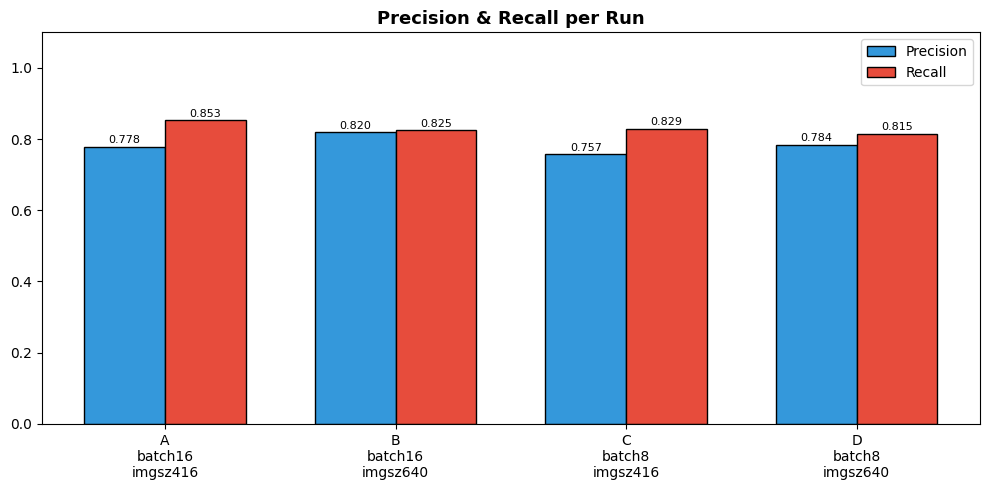

In [12]:
# ── Grouped bar — precision & recall per run ───────────────────────────
x     = np.arange(len(df_results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, df_results["precision"].astype(float), width, label="Precision", color="#3498db", edgecolor="black")
b2 = ax.bar(x + width/2, df_results["recall"].astype(float),    width, label="Recall",    color="#e74c3c", edgecolor="black")
ax.set_title("Precision & Recall per Run", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(run_labels)
ax.set_ylim(0, 1.1)
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("../results/figures/hyperparameter_comparison_prec_recall.png", dpi=150, bbox_inches="tight")
plt.show()

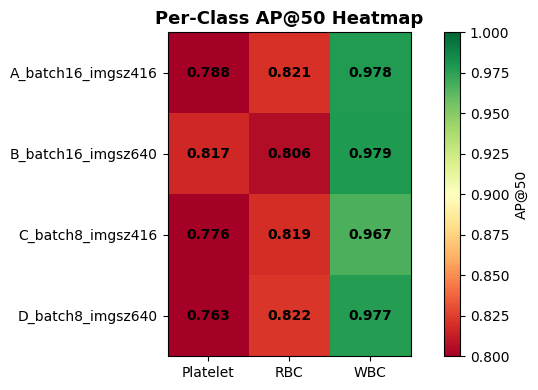

Saved: ../results/figures/per_class_ap50_heatmap.png


In [13]:
# ── Per-class AP@50 heatmap ────────────────────────────────────────────
heat_data = df_results[["ap50_platelet","ap50_rbc","ap50_wbc"]].astype(float).values

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(heat_data, cmap="RdYlGn", vmin=0.8, vmax=1.0)
plt.colorbar(im, ax=ax, label="AP@50")
ax.set_xticks([0,1,2])
ax.set_xticklabels(["Platelet","RBC","WBC"])
ax.set_yticks(range(len(df_results)))
ax.set_yticklabels(df_results["run"].str.replace("run_",""))
ax.set_title("Per-Class AP@50 Heatmap", fontsize=13, fontweight="bold")
for i in range(len(df_results)):
    for j in range(3):
        ax.text(j, i, f"{heat_data[i,j]:.3f}", ha="center", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/per_class_ap50_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../results/figures/per_class_ap50_heatmap.png")

## 9. Select the Best Model

In [14]:
# Rank by mAP@50 (primary) then mAP@50-95 (tiebreak)
df_ranked = df_results.copy()
df_ranked["mAP50"]    = df_ranked["mAP50"].astype(float)
df_ranked["mAP50_95"] = df_ranked["mAP50_95"].astype(float)
df_ranked = df_ranked.sort_values(["mAP50","mAP50_95"], ascending=False).reset_index(drop=True)

best_run  = df_ranked.iloc[0]
best_name = best_run["run"]

print("\nRanking (best → worst by mAP@50):")
print(df_ranked[["run","mAP50","mAP50_95","precision","recall"]].to_string(index=False))
print(f"\n🏆 Best run: {best_name}")
print(f"   mAP@50    : {best_run['mAP50']}")
print(f"   mAP@50-95 : {best_run['mAP50_95']}")
print(f"   Precision  : {best_run['precision']}")
print(f"   Recall     : {best_run['recall']}")

# Load the best model for downstream evaluation
best_pt_path  = Path(run_results[best_name]["best_pt"])
best_save_dir = Path(run_results[best_name]["save_dir"])
best_model    = YOLO(str(best_pt_path))
print(f"\nBest model loaded from: {best_pt_path}")


Ranking (best → worst by mAP@50):
                   run  mAP50  mAP50_95 precision  recall
run_B_batch16_imgsz640 0.8671    0.6270    0.8195  0.8253
run_A_batch16_imgsz416 0.8622    0.6082    0.7779  0.8527
 run_C_batch8_imgsz416 0.8542    0.6109     0.757  0.8289
 run_D_batch8_imgsz640 0.8541    0.6092    0.7839  0.8153

🏆 Best run: run_B_batch16_imgsz640
   mAP@50    : 0.8671
   mAP@50-95 : 0.627
   Precision  : 0.8195
   Recall     : 0.8253

Best model loaded from: ..\models\run_B_batch16_imgsz640_best.pt


## 10. Full Evaluation of Best Model

In [15]:
# Full validation with plots (confusion matrix, PR curve, etc.)
metrics = best_model.val(
    data=str(yaml_path),
    split="val",
    plots=True,
    save_json=True,
    verbose=False,
)

print("\n" + "="*55)
print(" BEST MODEL — EVALUATION RESULTS")
print("="*55)
print(f" Run          : {best_name}")
print(f" Batch size   : {best_run['batch']}  |  Image size: {best_run['imgsz']}")
print("-"*55)
print(f" mAP@50       : {metrics.box.map50:.4f}")
print(f" mAP@50-95    : {metrics.box.map:.4f}")
print(f" Precision    : {metrics.box.mp:.4f}")
print(f" Recall       : {metrics.box.mr:.4f}")
print("-"*55)
print(" Per-Class AP@50:")
for cls_name, ap50 in zip(class_names, metrics.box.ap50):
    print(f"   {cls_name:<12}: {ap50:.4f}")
print("="*55)

Ultralytics 8.4.19  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 62.810.9 MB/s, size: 20.4 KB)
val: Scanning C:\Users\jchen\MiniProject7-BloodCellDetection\data\raw\BCCD-3\valid\labels.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.6s/it 8.1s0.6s1
                   all         73        967      0.819      0.825      0.867      0.627
Speed: 2.8ms preprocess, 8.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Saving C:\Users\jchen\MiniProject7-BloodCellDetection\notebooks\runs\detect\val5\predictions.json...
Results saved to C:\Users\jchen\MiniProject7-BloodCellDetection\notebooks\runs\detect\val5

 BEST MODEL — EVALUATION RESULTS
 Run          : run_B_batch16_imgsz640
 Batch size 

## 11. Training Curves — Best Model

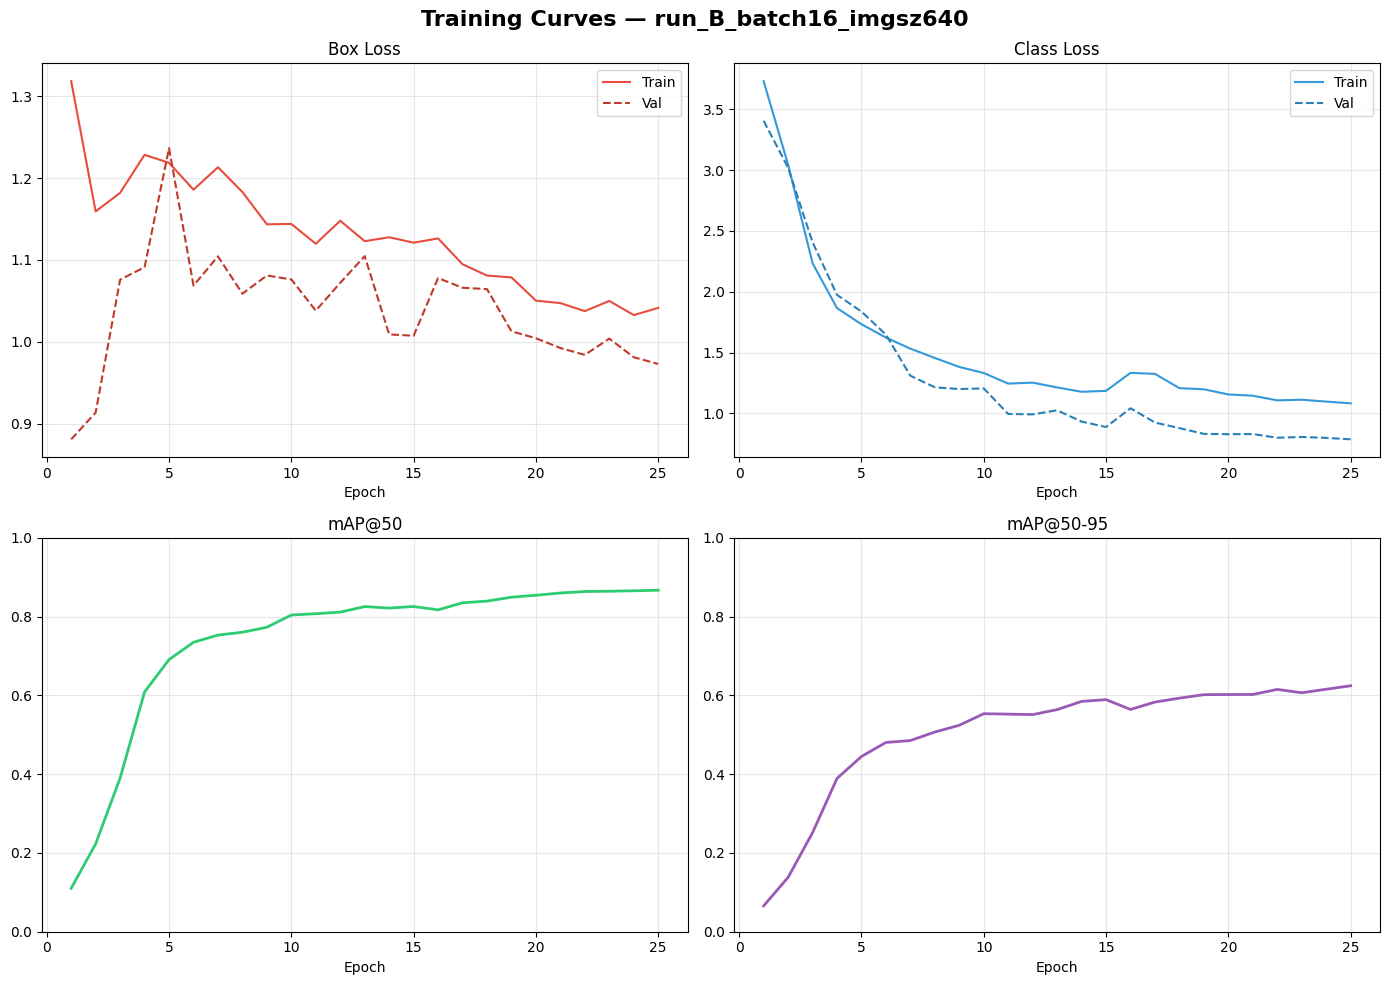

Saved: ../results/figures/training_curves_best.png


In [16]:
results_csv = best_save_dir / "results.csv"
df_train    = pd.read_csv(results_csv)
df_train.columns = df_train.columns.str.strip()

epochs = df_train["epoch"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Training Curves — {best_name}", fontsize=16, fontweight="bold")

axes[0,0].plot(epochs, df_train["train/box_loss"], label="Train", color="#e74c3c")
axes[0,0].plot(epochs, df_train["val/box_loss"],   label="Val",   color="#c0392b", linestyle="--")
axes[0,0].set_title("Box Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()

axes[0,1].plot(epochs, df_train["train/cls_loss"], label="Train", color="#3498db")
axes[0,1].plot(epochs, df_train["val/cls_loss"],   label="Val",   color="#2980b9", linestyle="--")
axes[0,1].set_title("Class Loss"); axes[0,1].set_xlabel("Epoch"); axes[0,1].legend()

axes[1,0].plot(epochs, df_train["metrics/mAP50(B)"],    color="#2ecc71", linewidth=2)
axes[1,0].set_title("mAP@50"); axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylim(0, 1)

axes[1,1].plot(epochs, df_train["metrics/mAP50-95(B)"], color="#9b59b6", linewidth=2)
axes[1,1].set_title("mAP@50-95"); axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylim(0, 1)

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/training_curves_best.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../results/figures/training_curves_best.png")

## 12. Per-Class AP@50 

Class                AP@50     AP@50-95
----------------------------------------
Platelets           0.8168       0.4959
RBC                 0.8057       0.5795
WBC                 0.9787       0.8057
----------------------------------------
mAP (mean)          0.8671       0.6270


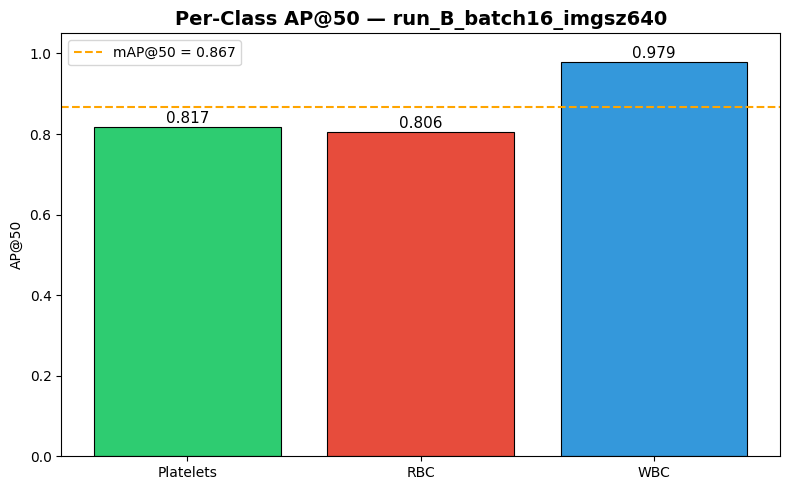

In [17]:
per_class_ap50 = metrics.box.ap50
per_class_ap   = metrics.box.ap

print(f"{'Class':<15} {'AP@50':>10} {'AP@50-95':>12}")
print("-" * 40)
for cls_name, ap50, ap in zip(class_names, per_class_ap50, per_class_ap):
    print(f"{cls_name:<15} {ap50:>10.4f} {ap:>12.4f}")
print("-" * 40)
print(f"{'mAP (mean)':<15} {metrics.box.map50:>10.4f} {metrics.box.map:>12.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_names, per_class_ap50, color=["#2ecc71", "#e74c3c", "#3498db"], edgecolor="black", linewidth=0.8)
ax.set_title(f"Per-Class AP@50 — {best_name}", fontsize=14, fontweight="bold")
ax.set_ylabel("AP@50")
ax.set_ylim(0, 1.05)
ax.axhline(y=metrics.box.map50, color="orange", linestyle="--", label=f"mAP@50 = {metrics.box.map50:.3f}")
ax.legend()
for bar, val in zip(bars, per_class_ap50):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("../results/figures/per_class_ap50_best.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Confusion Matrix

Confusion matrix copied → ..\results\figures\confusion_matrix_best.png


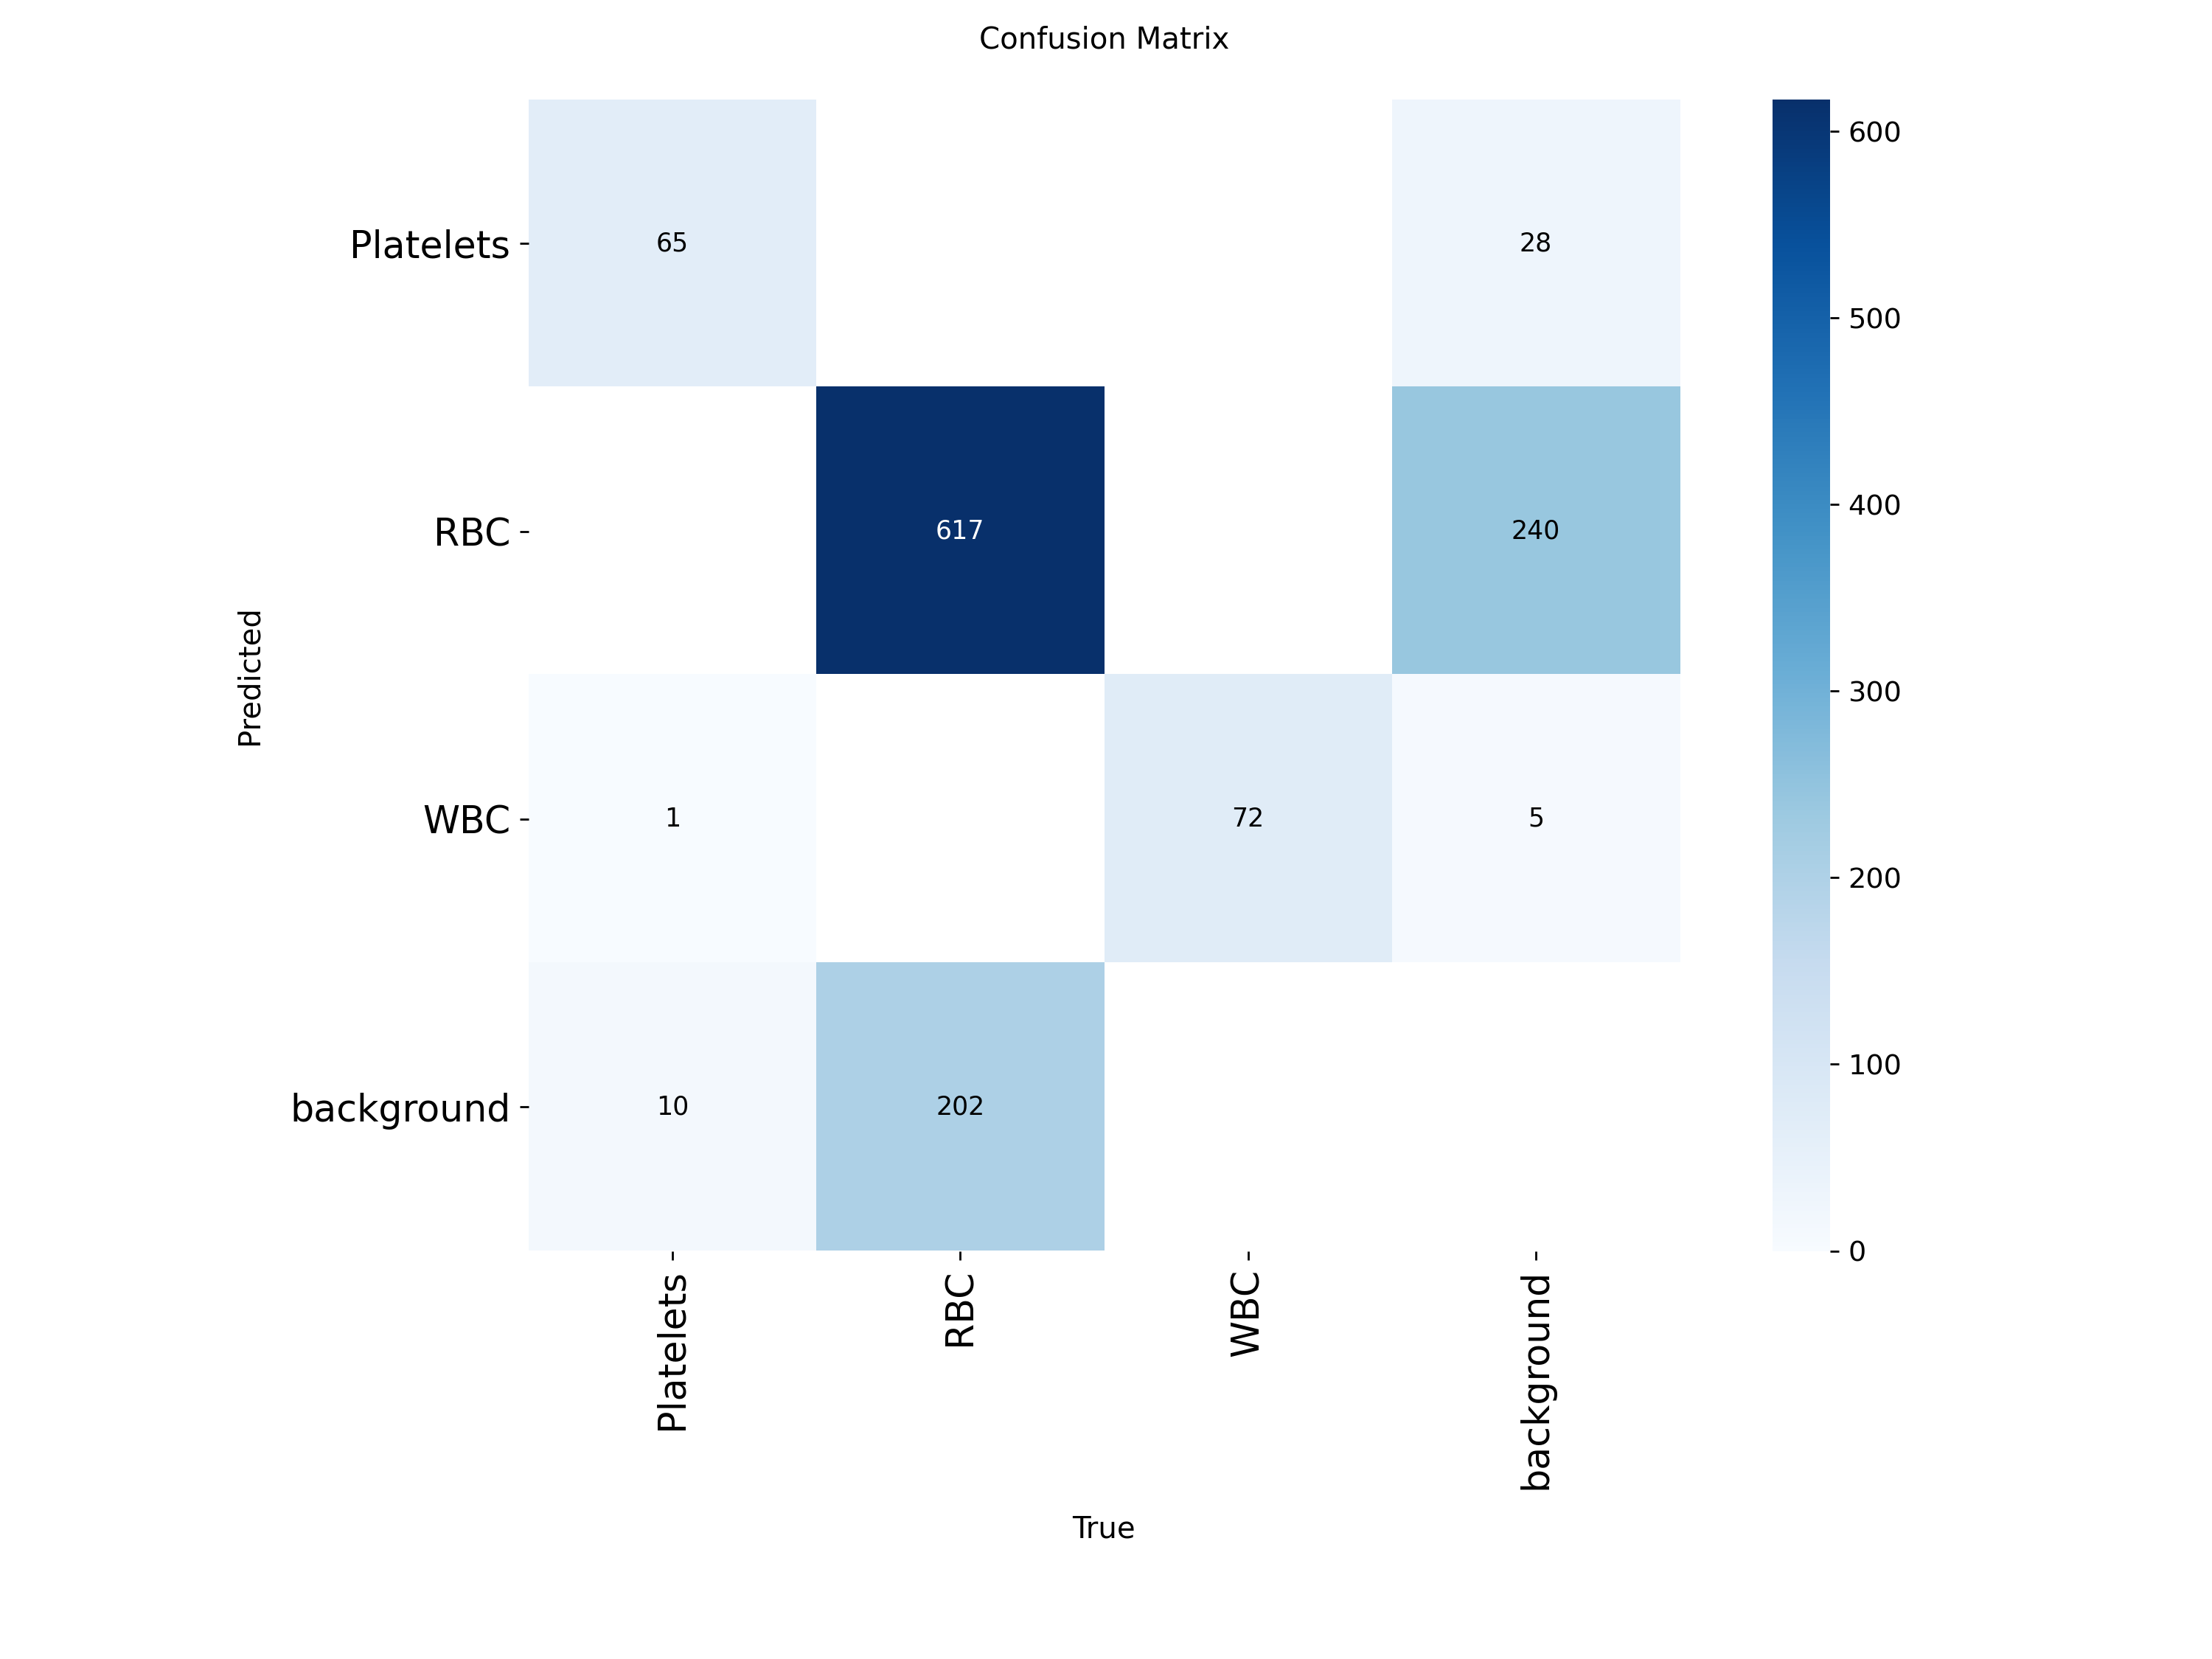

In [18]:
import shutil
cm_src  = best_save_dir / "confusion_matrix.png"
cm_dest = Path("../results/figures/confusion_matrix_best.png")
if cm_src.exists():
    shutil.copy2(cm_src, cm_dest)
    print(f"Confusion matrix copied → {cm_dest}")
    display(Image(filename=str(cm_src)))
else:
    print("Confusion matrix not found — run val with plots=True first.")

## 14. Predictions vs Ground Truth 

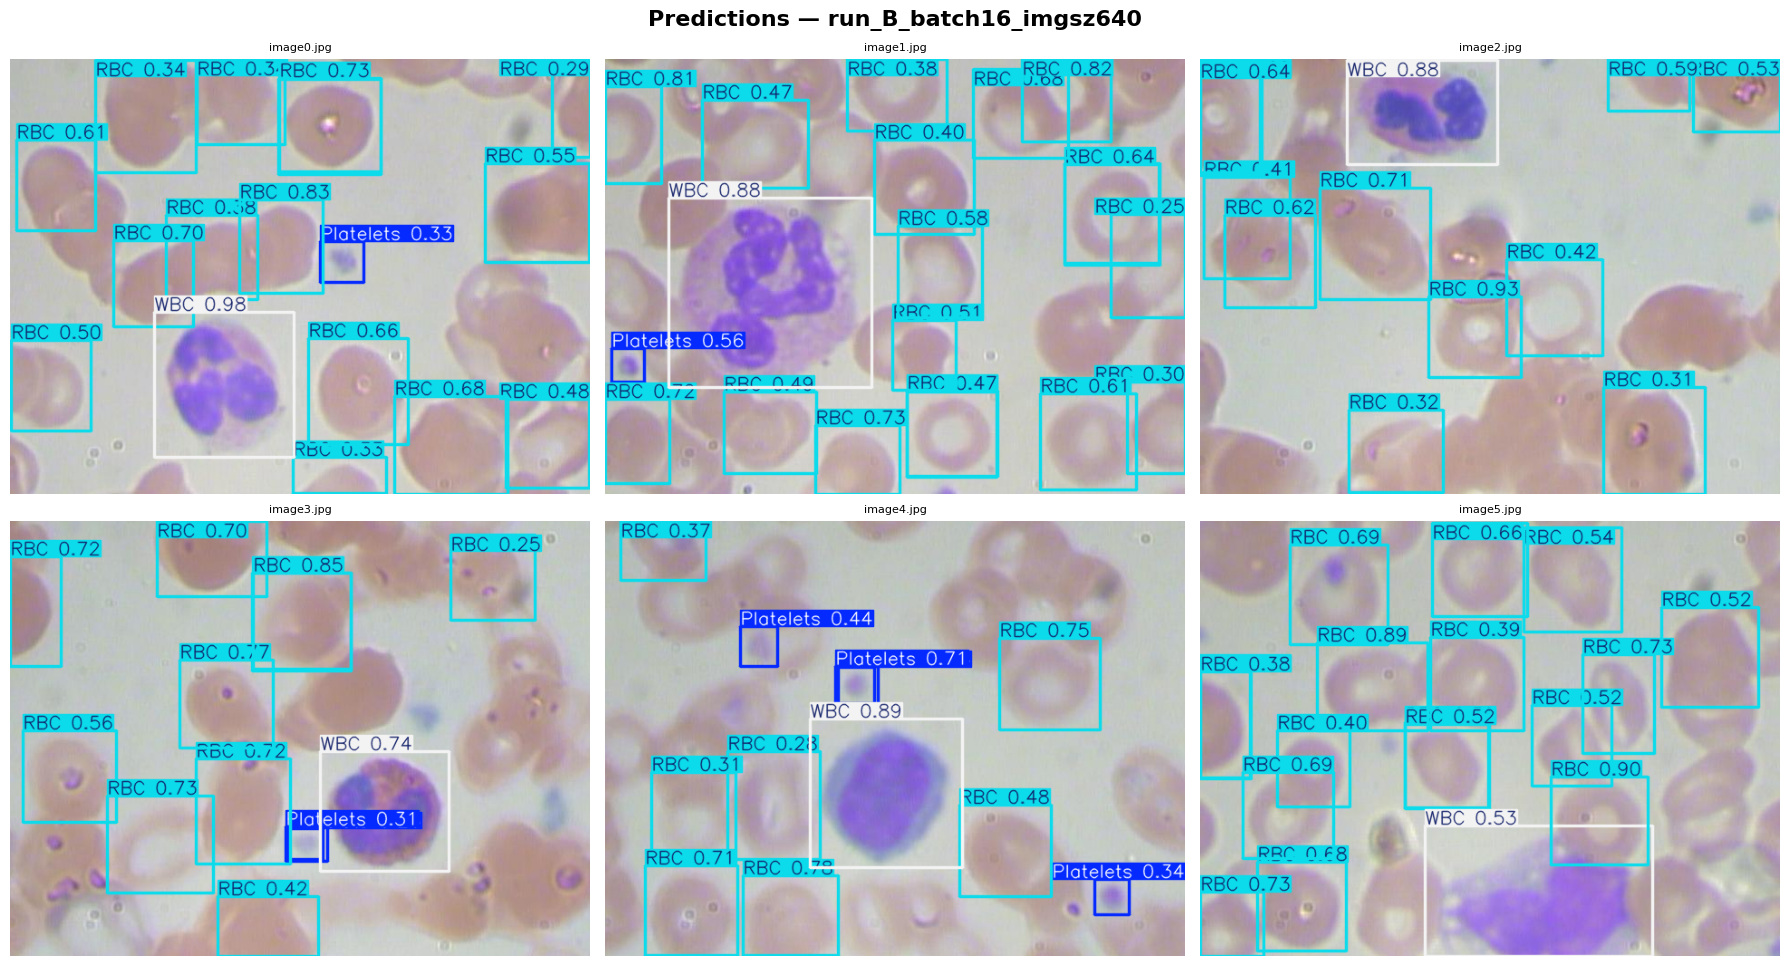

Saved: ../results/figures/val_predictions_best.png


In [19]:
val_images_dir = dataset_path / "valid" / "images"
val_images     = list(val_images_dir.glob("*.jpg")) + list(val_images_dir.glob("*.png"))
sample_val     = random.sample(val_images, min(6, len(val_images)))

predictions = best_model.predict(
    source=sample_val, conf=0.25, iou=0.45, save=False, verbose=False
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Predictions — {best_name}", fontsize=16, fontweight="bold")

for ax, result in zip(axes.flatten(), predictions):
    annotated_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(annotated_rgb)
    ax.set_title(Path(result.path).name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../results/figures/val_predictions_best.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../results/figures/val_predictions_best.png")

## 15. Incorrect Predictions 

Found 6 images with mismatched predictions


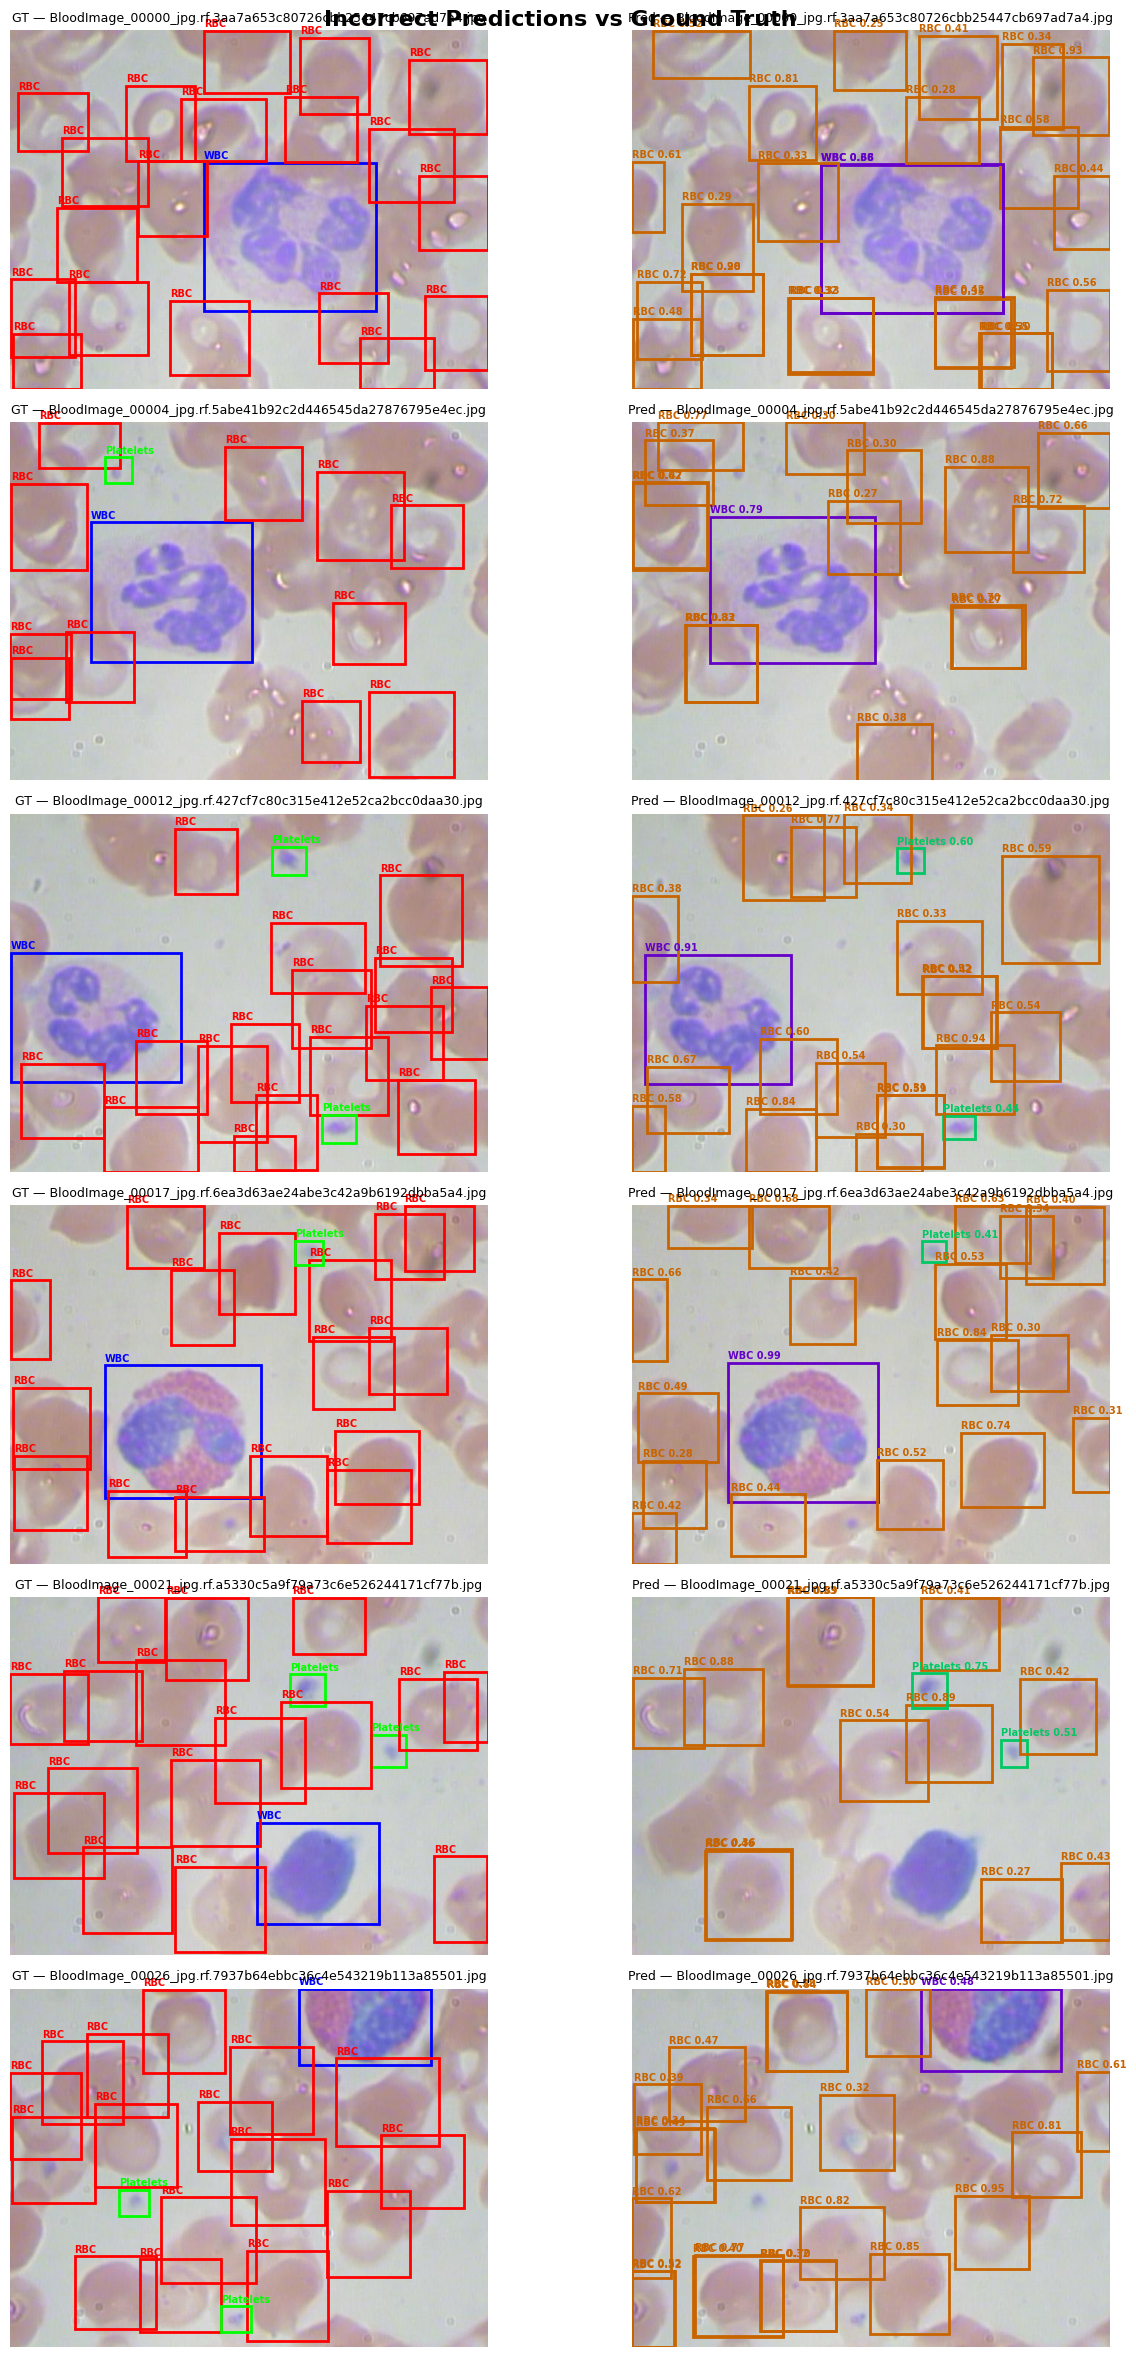

Saved: ../results/figures/incorrect_predictions_best.png


In [20]:
colors_gt   = {"Platelet": (0, 255, 0),   "RBC": (255, 0, 0),   "WBC": (0, 0, 255)}
colors_pred = {"Platelet": (0, 200, 100),  "RBC": (200, 100, 0),  "WBC": (100, 0, 200)}

def load_gt_boxes(image_path, dataset_path):
    label_path = Path(dataset_path) / "valid" / "labels" / (Path(image_path).stem + ".txt")
    boxes = []
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                boxes.append((int(parts[0]), *map(float, parts[1:5])))
    return boxes

def yolo_to_pixel(cx, cy, w, h, img_w, img_h):
    return (int((cx-w/2)*img_w), int((cy-h/2)*img_h),
            int((cx+w/2)*img_w), int((cy+h/2)*img_h))

def has_mismatch(gt_boxes, pred_boxes):
    if not gt_boxes or not pred_boxes:
        return True
    return Counter(b[0] for b in gt_boxes) != Counter(int(b[5]) for b in pred_boxes)

incorrect_examples = []
for img_path in val_images:
    img = cv2.imread(str(img_path))
    img_h, img_w = img.shape[:2]
    gt_boxes = load_gt_boxes(img_path, dataset_path)
    result   = best_model.predict(str(img_path), conf=0.25, iou=0.45, verbose=False)[0]
    pred_boxes = []
    if result.boxes is not None:
        for box in result.boxes:
            x1,y1,x2,y2 = box.xyxy[0].tolist()
            pred_boxes.append((x1,y1,x2,y2, float(box.conf[0]), int(box.cls[0])))
    if has_mismatch(gt_boxes, pred_boxes):
        incorrect_examples.append((img_path, img, gt_boxes, pred_boxes, img_w, img_h))
    if len(incorrect_examples) >= 6:
        break

print(f"Found {len(incorrect_examples)} images with mismatched predictions")

fig, axes = plt.subplots(len(incorrect_examples), 2,
                         figsize=(14, 4*len(incorrect_examples)))
fig.suptitle("Incorrect Predictions vs Ground Truth", fontsize=16, fontweight="bold")

for i, (img_path, img, gt_boxes, pred_boxes, img_w, img_h) in enumerate(incorrect_examples):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax_gt   = axes[i,0] if len(incorrect_examples) > 1 else axes[0]
    ax_pred = axes[i,1] if len(incorrect_examples) > 1 else axes[1]

    ax_gt.imshow(img_rgb)
    for cls_id, cx, cy, w, h in gt_boxes:
        x1,y1,x2,y2 = yolo_to_pixel(cx, cy, w, h, img_w, img_h)
        color = [c/255 for c in list(colors_gt.values())[cls_id]]
        ax_gt.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1, linewidth=2, edgecolor=color, facecolor='none'))
        ax_gt.text(x1, y1-5, class_names[cls_id], color=color, fontsize=7, fontweight='bold')
    ax_gt.set_title(f"GT — {Path(img_path).name}", fontsize=9)
    ax_gt.axis("off")

    ax_pred.imshow(img_rgb)
    for x1,y1,x2,y2,conf,cls_id in pred_boxes:
        color = [c/255 for c in list(colors_pred.values())[cls_id]]
        ax_pred.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1, linewidth=2, edgecolor=color, facecolor='none'))
        ax_pred.text(x1, y1-5, f"{class_names[cls_id]} {conf:.2f}", color=color, fontsize=7, fontweight='bold')
    ax_pred.set_title(f"Pred — {Path(img_path).name}", fontsize=9)
    ax_pred.axis("off")

plt.tight_layout()
plt.savefig("../results/figures/incorrect_predictions_best.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../results/figures/incorrect_predictions_best.png")

## 16. Final Summary

In [21]:
print("=" * 60)
print(" MEDSCAN DIAGNOSTICS — HYPERPARAMETER EXPERIMENT SUMMARY")
print("=" * 60)
print(f" Model Architecture : YOLO26n (pretrained on COCO)")
print(f" Dataset            : BCCD — Blood Cell Detection")
print(f" Classes            : {', '.join(class_names)}")
print(f" Epochs per run     : 25")
print()
print(" All Runs (ranked by mAP@50):")
print(f" {'Run':<30} {'Batch':>5} {'Imgsz':>6} {'mAP50':>7} {'mAP50-95':>9}")
print("-" * 60)
for _, row in df_ranked.iterrows():
    marker = " 🏆" if row["run"] == best_name else ""
    print(f" {row['run']:<30} {int(row['batch']):>5} {int(row['imgsz']):>6}"
          f" {float(row['mAP50']):>7.4f} {float(row['mAP50_95']):>9.4f}{marker}")
print("=" * 60)
print(f"\n🏆 BEST CONFIG: {best_name}")
print(f"   Batch={best_run['batch']}, imgsz={best_run['imgsz']}")
print(f"   mAP@50={best_run['mAP50']}  |  Precision={best_run['precision']}  |  Recall={best_run['recall']}")
print()
print(" Per-Class AP@50 (best model):")
for cls_name, ap50 in zip(class_names, metrics.box.ap50):
    print(f"   {cls_name:<12}: {ap50:.4f}")
print("=" * 60)
print(f"\n Best weights : {run_results[best_name]['best_pt']}")
print(f" Figures      : ../results/figures/")
print(f" Metrics CSV  : {metrics_csv}")

 MEDSCAN DIAGNOSTICS — HYPERPARAMETER EXPERIMENT SUMMARY
 Model Architecture : YOLO26n (pretrained on COCO)
 Dataset            : BCCD — Blood Cell Detection
 Classes            : Platelets, RBC, WBC
 Epochs per run     : 25

 All Runs (ranked by mAP@50):
 Run                            Batch  Imgsz   mAP50  mAP50-95
------------------------------------------------------------
 run_B_batch16_imgsz640            16    640  0.8671    0.6270 🏆
 run_A_batch16_imgsz416            16    416  0.8622    0.6082
 run_C_batch8_imgsz416              8    416  0.8542    0.6109
 run_D_batch8_imgsz640              8    640  0.8541    0.6092

🏆 BEST CONFIG: run_B_batch16_imgsz640
   Batch=16, imgsz=640
   mAP@50=0.8671  |  Precision=0.8195  |  Recall=0.8253

 Per-Class AP@50 (best model):
   Platelets   : 0.8168
   RBC         : 0.8057
   WBC         : 0.9787

 Best weights : ..\models\run_B_batch16_imgsz640_best.pt
 Figures      : ../results/figures/
 Metrics CSV  : ..\results\metrics\hyperparameter_

## Analysis

### 1. Dataset Class Balance and Its Impact on Model Performance

The BCCD training set is severely imbalanced: RBC dominates with 2,938 instances, while Platelets (249) and WBC (263) together account for less than 15% of all labeled objects. This ~12:1 ratio between RBC and the minority classes has meaningful consequences for training.

Interestingly, the imbalance did not hurt WBC detection as it achieved the highest AP@50 at **0.9787**, likely because WBCs are visually distinctive (large, dark-stained nuclei) and easy to separate from other classes regardless of how few training examples exist. RBC, despite being the majority class, scores the lowest at **0.8057**. This is because RBCs are densely packed and visually similar to each other, making precise localization harder even with abundant examples. Platelets sit in the middle at **0.8168**, which is reasonable given their small size and low instance count.

The practical takeaway: class imbalance is less of a concern here than object appearance and density. Future work should focus on augmenting Platelet and RBC examples with varied crowding and lighting conditions rather than simply adding more images.

### 2. Confidence Thresholds for the Medical Domain

The default confidence threshold of **0.25** used during inference is appropriate for development but too low for clinical deployment. At 0.25, the model surfaces many marginal detections, increasing false positives, which is acceptable when exploring, but problematic in a diagnostic workflow.

For clinical use, a threshold of **0.50–0.60** is recommended:

- **Below 0.50**: False positive rates rise sharply. A spurious WBC detection could incorrectly suggest leukocytosis or infection.
- **Above 0.70**: Recall drops enough that genuine cells are missed, which is the more dangerous error in this context.
- **~0.55** balances these concerns and keeps the model conservative enough to serve as a reliable screening aid.

The ideal threshold should ultimately be determined empirically by plotting the precision-recall curve per class at multiple thresholds on a held-out clinical test set, and not just the Roboflow validation split.

### 3. Which Classes the Model Struggles With Most, and Why

**RBC** is the most difficult class (AP@50 = 0.8057), followed by **Platelets** (0.8168). **WBC** is handled confidently (0.9787).

**RBC** struggles primarily because of density and overlap. Blood smear images can contain dozens of RBCs in a single frame, many of which overlap or are partially occluded. YOLO's NMS can suppress valid detections when boxes overlap heavily. The confusion matrix showed 91 RBCs classified as background, which means these are likely cells at the edges of clusters that the model gives up on.

**Platelets** struggle due to their small size relative to the 640×640 input resolution. Small objects are a known weakness of single-stage detectors like YOLO, as they occupy very few feature map cells at deeper network layers. The 23 Platelets misclassified as background are consistent with this — the model is simply not seeing them.

**WBC** excels because each WBC is visually unique (large, purple-stained, irregularly shaped nucleus), typically appears alone or in small numbers, and is well-separated from other cells. It is an easy target for a convolutional detector.

### 4. False Positives vs. False Negatives: Which Is More Dangerous?

In this medical context, **false negatives are more dangerous** than false positives, but the answer varies by cell type.

| Cell Type | More Dangerous Error | Clinical Consequence |
|-----------|---------------------|---------------------|
| WBC | False Negative | Missing WBCs could delay diagnosis of infection, leukemia, or immune disorders |
| Platelet | False Negative | Undercounting platelets could contribute to a missed thrombocytopenia diagnosis, carrying real bleeding risk |
| RBC | False Negative | Inaccurate RBC counts affect anemia diagnosis; 91 RBCs missed as background is the model's weakest point |

False positives, while less dangerous, still carry cost: they could trigger unnecessary follow-up tests, add clinician burden, and erode trust in the tool. In a clinical workflow designed as a *screening aid* (not a replacement for lab analysis), a slightly higher false positive rate is more tolerable than missing real pathology.

### 5. Business Recommendation: Is the Model Ready for Clinical Deployment?

**Not yet for standalone diagnostic use but yes as a screening aid with human oversight.**

The best model (Run B: batch=16, imgsz=640, mAP@50=0.8671) shows genuinely strong WBC performance, but RBC (0.8057) and Platelet (0.8168) accuracy fall short of the reliability standard expected in a clinical diagnostic tool where errors directly affect patient care.

**What would be needed before clinical deployment:**

1. **More training data.** 255 training images is small for a medical application. A dataset of 2,000–5,000 annotated images sourced from multiple labs and staining protocols would substantially improve generalization.
2. **Better small object detection.** For Platelets specifically, techniques like SAHI (Slicing Aided Hyper Inference) or training at higher resolutions (e.g., 1280px) would help.
3. **Independent clinical validation.** The Roboflow validation split comes from the same distribution as training data. A prospective evaluation on images from a separate hospital or lab is essential before any clinical claim can be made.
4. **Per-class threshold tuning.** Rather than one global confidence threshold, each class should have its own calibrated threshold optimized for its clinical stakes.
5. **Regulatory approval.** In Canada, a tool used to inform clinical decisions is classified as a medical device requiring Health Canada approval (Class II or higher), independent of model accuracy.

**Recommendation:** Deploy the current model as an internal research prototype or lab workflow assistant. For example, automating cell counting for quality control while continuing to improve the model and dataset in parallel. It should not be used as the sole basis for clinical diagnosis without a licensed pathologist in the loop.